# DNA Splice Junction Classification
## Support Vector Machine (SVM)

In the previous notebook, I converted the DNA sequences into 3-mer frequency features.

Now I will train a Support Vector Machine (SVM) to classify the sequences into the three splice-junction classes: `EI`, `IE`, and `N`.

I will first prepare the data correctly, then train the SVM and evaluate its initial performance.

In [1]:
from pathlib import Path
import pandas as pd

FEATURE_PATH = Path("../data/processed")

X = pd.read_csv(FEATURE_PATH / "kmer_features.csv")
y = pd.read_csv(FEATURE_PATH / "kmer_target.csv").squeeze()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (3178, 97)
Target shape: (3178,)


## 2. Train-Test Split

### WHY

I need to separate the data into training and testing sets before training the model.

The training set will be used to learn the relationship between k-mer features and splice-junction classes.

The test set will remain unseen during training and will be used to evaluate how well the model generalizes to new observations.

I will use a **stratified 80/20 split** so that the class proportions are approximately preserved in both sets.

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (2542, 97)
Testing shape: (636, 97)


In [3]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training class distribution:
class
N     52.08
IE    23.96
EI    23.96
Name: proportion, dtype: float64

Testing class distribution:
class
N     52.04
IE    24.06
EI    23.90
Name: proportion, dtype: float64


### FIND

The stratified split preserved the original class distribution closely.

The training and testing sets contain approximately:
- `N`: 52%
- `IE`: 24%
- `EI`: 24%

This means the test set remains representative of the overall class distribution.

### DECIDE

I will use this 80/20 stratified split consistently for the SVM and Random Forest models.

The `random_state=42` will also be kept fixed so that the experiments are reproducible.

## 3. Feature Scaling

### WHY

SVM is sensitive to the scale of input features because it uses distances and margins when finding the decision boundaries.

Our k-mer features are count-based, so I will standardize the features before training the SVM.

The scaler will be fitted only on the training data to prevent information from the test set from leaking into the model.

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training shape: (2542, 97)
Testing shape: (636, 97)


### FIND

The training set contains 2,542 observations and the test set contains 636 observations, with 97 k-mer features in both.

The SVM input features have now been standardized using statistics learned only from the training data.

### DECIDE

I will use the scaled features for SVM training.

The test data has not been used to fit the scaler, so the evaluation remains independent of the test set.

## 4. Training the SVM

### WHY

I will now train a Support Vector Machine using the 3-mer frequency features.

SVM is suitable for this problem because it can learn nonlinear decision boundaries when the relationship between k-mer patterns and splice-junction classes is not simply linear.

I will start with an RBF kernel and use the default `C` value of 1.0 as the initial baseline.

In [6]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM training completed.")

SVM training completed.


In [7]:
y_pred_svm = svm_model.predict(X_test_scaled)

print("Predictions generated:", len(y_pred_svm))

Predictions generated: 636


### FIND

The trained SVM generated predictions for all 636 observations in the test set.

I can now compare these predictions with the true class labels to measure the model's classification performance.

In [8]:
from sklearn.metrics import accuracy_score, classification_report

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {svm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.6745

Classification Report:
              precision    recall  f1-score   support

          EI       0.68      0.57      0.62       152
          IE       0.67      0.49      0.57       153
           N       0.67      0.81      0.74       331

    accuracy                           0.67       636
   macro avg       0.68      0.62      0.64       636
weighted avg       0.67      0.67      0.67       636



NameError: name 'plt' is not defined

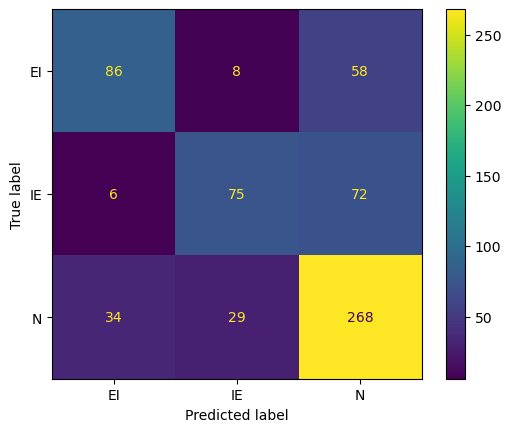

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    values_format="d"
)

plt.title("SVM Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/figures/svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1]
}

grid_search = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Best Parameters: {'C': 1, 'gamma': 0.01}
Best Cross-Validation Accuracy: 0.6684


In [13]:
#Create the Tuned SVM
best_svm = grid_search.best_estimator_

y_pred_tuned_svm = best_svm.predict(X_test_scaled)

print("Tuned SVM predictions generated:", len(y_pred_tuned_svm))

Tuned SVM predictions generated: 636


In [14]:
#evaluate  tuned SVM
from sklearn.metrics import accuracy_score, classification_report

tuned_svm_accuracy = accuracy_score(y_test, y_pred_tuned_svm)

print(f"Tuned SVM Accuracy: {tuned_svm_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned_svm))

Tuned SVM Accuracy: 0.6714

Classification Report:
              precision    recall  f1-score   support

          EI       0.68      0.55      0.61       152
          IE       0.66      0.50      0.57       153
           N       0.67      0.81      0.73       331

    accuracy                           0.67       636
   macro avg       0.67      0.62      0.64       636
weighted avg       0.67      0.67      0.66       636



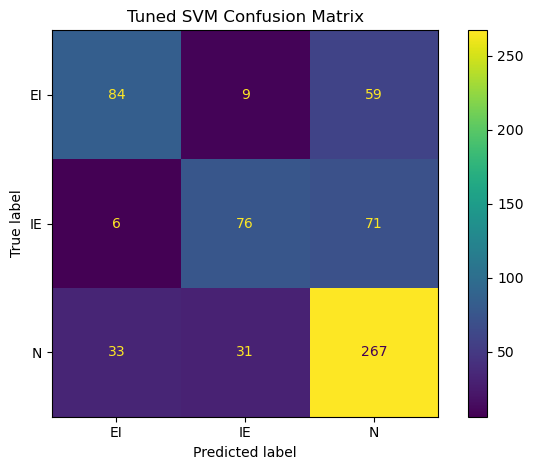

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tuned_svm,
    values_format="d"
)

plt.title("Tuned SVM Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "../reports/figures/tuned_svm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
print(f"Baseline SVM Accuracy: {svm_accuracy:.4f}")
print(f"Tuned SVM Accuracy:    {tuned_svm_accuracy:.4f}")

Baseline SVM Accuracy: 0.6745
Tuned SVM Accuracy:    0.6714


### FIND

The baseline SVM achieved an accuracy of 67.45% on the test set.  
After tuning the `C` and `gamma` hyperparameters, the tuned SVM achieved 67.14%, which was slightly lower than the baseline.

### DECIDE

I will retain the baseline SVM as the final SVM model because hyperparameter tuning did not improve its test accuracy. This gives us a simple and stable baseline for comparison with the Random Forest model.

In [17]:
final_svm = svm_model

print("Final SVM model selected.")
print(f"Test Accuracy: {svm_accuracy:.4f}")

Final SVM model selected.
Test Accuracy: 0.6745


## Summary

In this notebook, I built an SVM classifier using the 3-mer features created in the previous notebook.

The workflow included:
- Splitting the dataset into training and testing sets using stratification.
- Standardizing the k-mer features.
- Training an RBF-kernel SVM as the baseline model.
- Evaluating the baseline model using accuracy, classification metrics, and a confusion matrix.
- Tuning the `C` and `gamma` hyperparameters using cross-validation.
- Comparing the baseline and tuned SVM models.

The baseline SVM achieved a test accuracy of **67.45%**, while the tuned SVM achieved **67.14%**. Since tuning did not improve performance, I retained the baseline SVM as the final SVM model.

The final SVM will be used as the benchmark for comparison with the Random Forest model in the later evaluation stage.